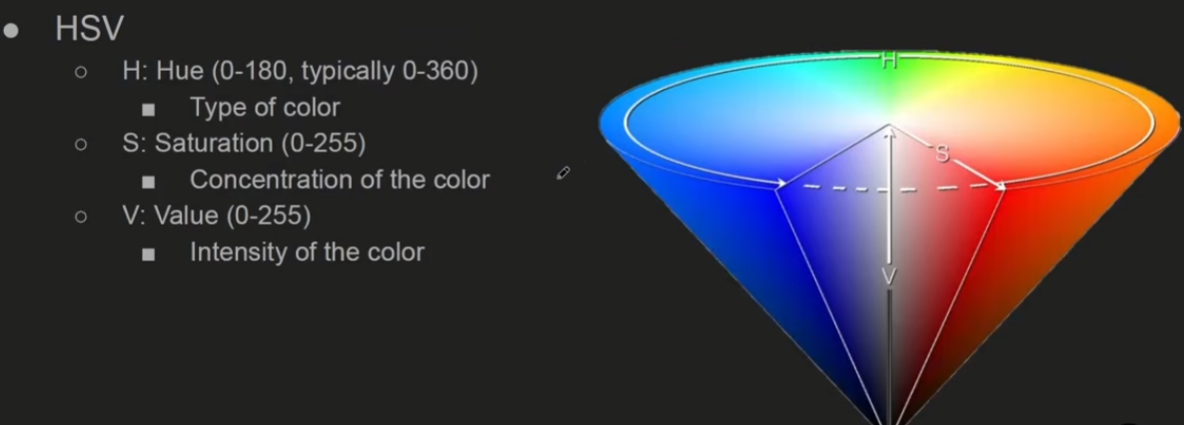
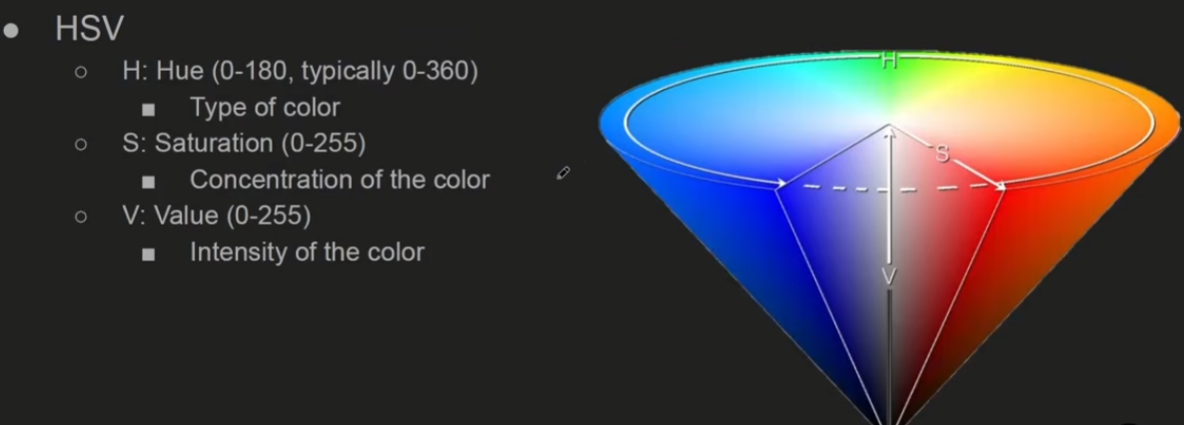
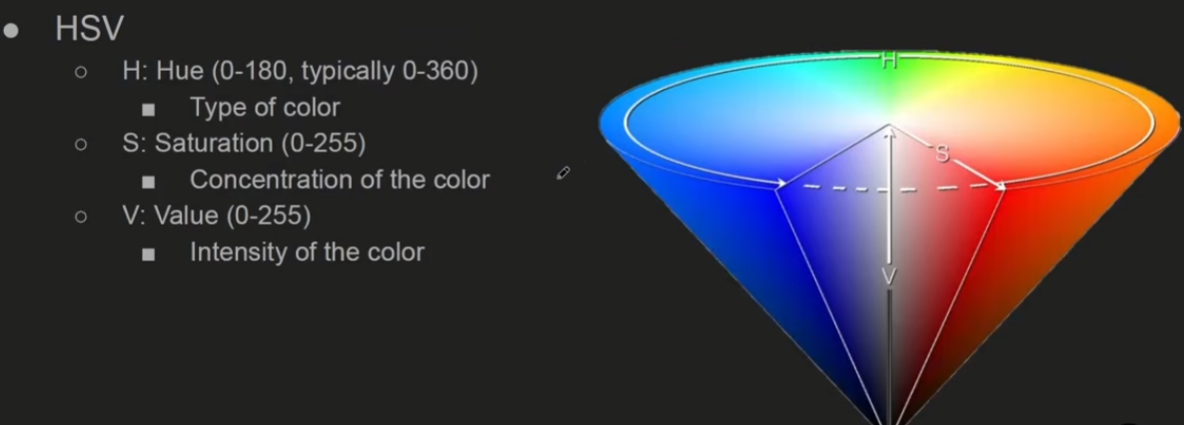
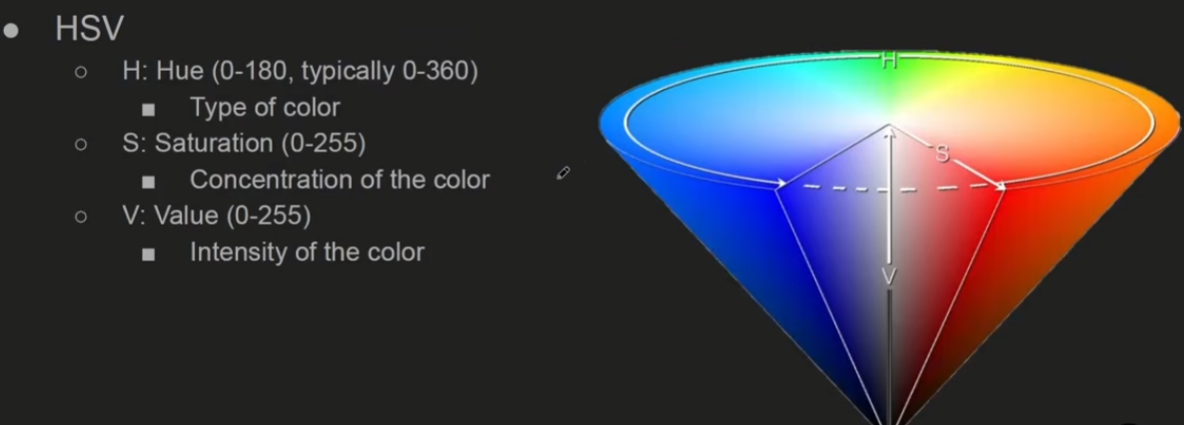

### HOW  does the HSV color space work

1. Divide r, g, b by 255
2. Compute `cmax`, `cmin` difference
    ```
    cmax = max(r, g, b)
    cmin = main(r, g, b)
    diff = cmax - cmin
   ```
3. Hue calculation
   ```
   if cmmax == cmin:
        h = 0
   elif cmax == r:
        h = (60 * ((g - b) / diff) + 360) % 360
   elif cmax == g:
        h = (60 * ((b - r) / diff) + 120) % 360
   elif cmax == b:
        h = (60 * ((r - g) / diff) + 240) % 360

   ```
4. Saturation computation
   ```
   if cmax == 0:
        s = 0
   else:
        s = (diff / cmax) * 100
   ```
5. Value computation
   ```
   v = cmax * 100
   ```


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p
from infrastructure.utils.plotting import subplot

In [2]:
IMAGE_PATH = p.IMAGE_ASSETS / "cat1.png"

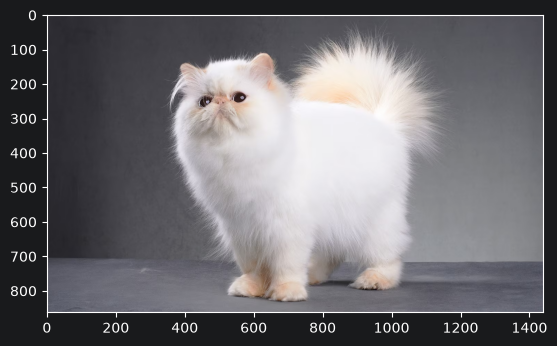

In [3]:
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(img_rgb)

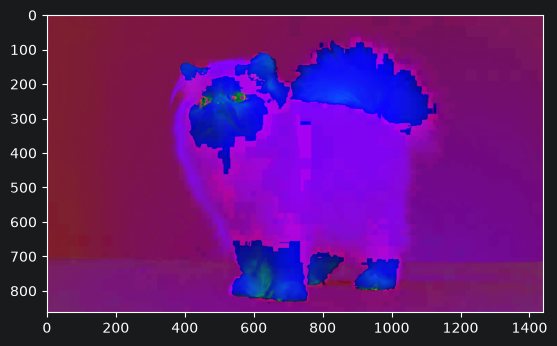

In [4]:
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
plt.figure()
plt.imshow(hsv)

In [5]:
# cv2.imshow("hsv", hsv)
# cv2.waitKey(0)

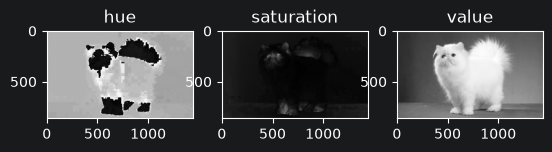

In [6]:
h, s, v = cv2.split(hsv)

data = dict(
    hue=h,
    saturation=s,
    value=v
)

subplot(data, cmap="gray")

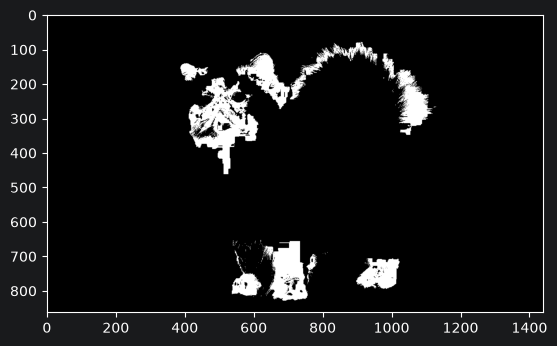

In [7]:
lower_bound = np.array([0, 0, 160])
upper_bound = np.array([13, 90, 230])
mask = cv2.inRange(hsv, lower_bound, upper_bound)
mask.shape
plt.figure()
plt.imshow(mask, cmap="gray")

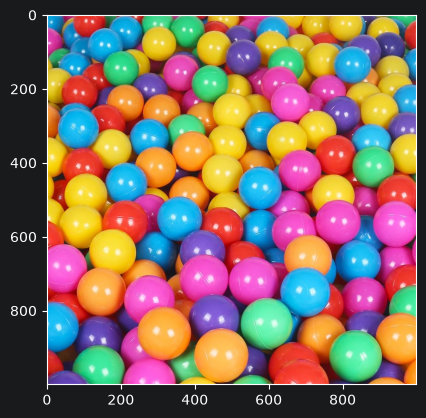

In [8]:
img_path = p.IMAGE_ASSETS / "colored_balls.jpg"
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(img_rgb)

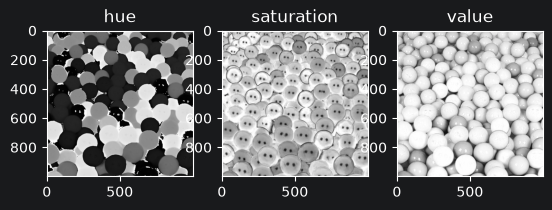

In [9]:
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv)
data = dict(
    hue=h,
    saturation=s,
    value=v
)
subplot(data, cmap="gray")

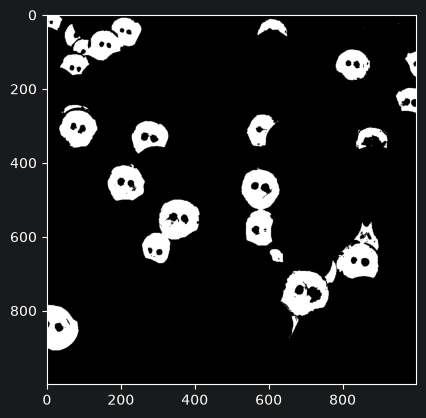

In [10]:
lower_bound = np.array([90, 200, 150])
upper_bound = np.array([110, 255, 255])
mask = cv2.inRange(hsv, lower_bound, upper_bound)

plt.figure()
plt.imshow(mask, cmap="gray")